# Imports

In [35]:
import os
import glob
import tempfile

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

from skimage.color import rgb2hed, rgb2gray
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import remove_small_holes
from skimage import measure

import pdnl_sana as sana
import pdnl_sana.logging
import pdnl_sana.slide
import pdnl_sana.image
import pdnl_sana.filter

### Visualization Helper Function

In [2]:
def show_tissue(tb, mask, title):
    """Overlay a binary tissue mask on the thumbnail."""
    # Convert the mask to a boolean array
    m = np.squeeze(np.asarray(mask)) > 0

    # Figure plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    ax[0].imshow(tb.img)
    ax[0].set_title('Thumbnail')
    ax[1].imshow(tb.img)
    ax[1].imshow(np.ma.masked_where(~m, m), cmap='autumn', alpha=0.4)
    ax[1].set_title(f'{title}  —  {100 * m.mean():.1f}% of thumbnail')
    
    for a in ax:
        a.axis('off')
    plt.tight_layout()
    plt.show()

# Tissue Segmentation Tests

### Loading the WSI to test

In [ ]:
WSI_dir_path = "/Users/hyroh/UPenn PhD/Published_Code/NEUSEG/Data"
WSI_file_name = "2017-187-48F_R_OFC_AT8_1K_01-25-23_PS.svs"
curr_WSI_path = os.path.join(WSI_dir_path, WSI_file_name)

logger = sana.logging.Logger('quiet', os.path.join(tempfile.gettempdir(), 'tissue_extraction.pkl'))
loader = sana.slide.Loader(logger, curr_WSI_path)
tb = loader.load_thumbnail()

print(f"level-0     : {loader.level_dimensions[0]}")
print(f"thumbnail   : {tuple(tb.size())}  (level {loader.thumbnail_level}, {loader.converter.ds[loader.thumbnail_level]:.1f}x)")

level-0     : (39840, 31947)
thumbnail   : (np.int64(2490), np.int64(1996))  (level 2, 16.0x)


### [1] pdnl_sana.slide.find_tissue

bodies: 47   holes: 35


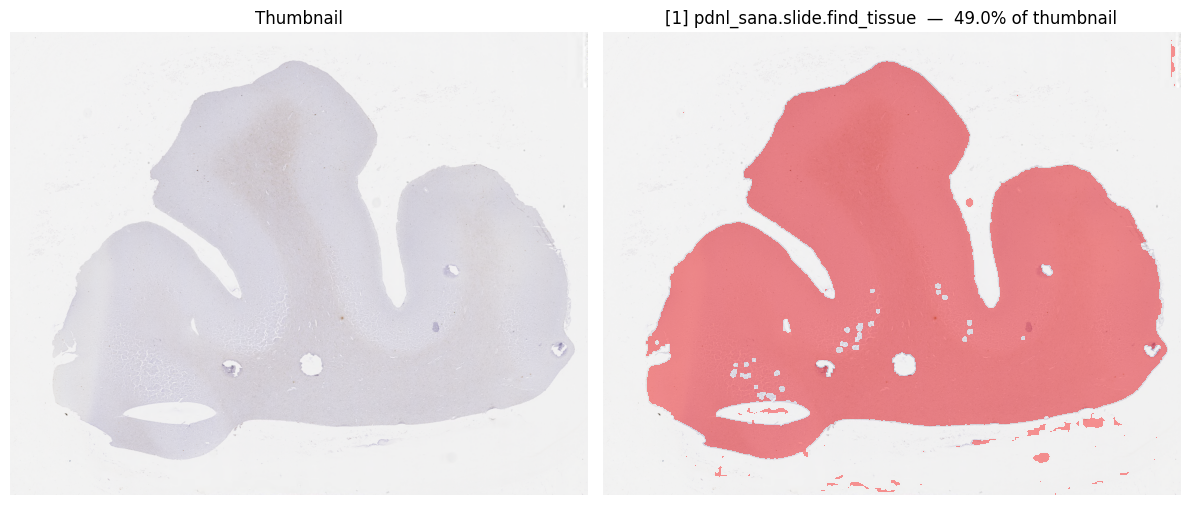

In [4]:
# As in neuseg/main.py :: run_cells()
tissue_mask_sana = sana.slide.find_tissue(tb)

if tissue_mask_sana is None:
    print("Cannot find tissue in slide!")
    rois, roi_holes = {}, []
else:
    rois, roi_holes = tissue_mask_sana.to_polygons()
    rois = {'Tissue': rois}
    print(f"bodies: {len(rois['Tissue'])}   holes: {len(roi_holes)}")
    show_tissue(tb, tissue_mask_sana.img, '[1] pdnl_sana.slide.find_tissue')

### [2] In original NEUSEG Paper

In [ ]:
WSI_dir_path = "/Volumes/Extreme SSD/bvFTD_Eval_cohort/FTLD-TDP"
WSI_file_name = "2002-238-10F_OFC_TDP43MP_1K_07-31-19_RL.svs"
curr_WSI_path = os.path.join(WSI_dir_path, WSI_file_name)

logger = sana.logging.Logger('quiet', os.path.join(tempfile.gettempdir(), 'tissue_extraction.pkl'))
loader = sana.slide.Loader(logger, curr_WSI_path)
tb = loader.load_thumbnail()

print(f"level-0     : {loader.level_dimensions[0]}")
print(f"thumbnail   : {tuple(tb.size())}  (level {loader.thumbnail_level}, {loader.converter.ds[loader.thumbnail_level]:.1f}x)")

level-0     : (37848, 26849)
thumbnail   : (np.int64(2365), np.int64(1678))  (level 2, 16.0x)


In [12]:
def get_tissue_mask(WSI_file_name, tb, debug_path=None):
    """Tissue mask as computed in script/Nuclei_Segmentation.py, '[1] Tissue Mask Extraction'.

    If `debug_path` is given, a per-stage debug figure is written to
    `debug_path/<WSI_file_name with .svs replaced by .png>`.
    """

    # --- (1) Color deconvolution --> Hematoxylin Channel ---
    # Hematoxylin OD
    HEM_SIGMA = 1.0  # blurring amount
    H = rgb2hed(tb.img.astype(np.float32) / 255.0)[..., 0].astype(np.float32)

    # Normalization
    perct = 5
    lo, hi = np.percentile(H, perct), np.percentile(H, 100 - perct)
    H_od = H.copy()                              # raw OD, kept for the debug figure
    clipped_lo, clipped_hi = H < lo, H > hi      # pixels the percentile clip normalizes out
    H = np.clip(H, lo, hi)
    H = (H - H.min()) / (H.max() - H.min() + 1e-8)

    # Blur slightly to stabilize thresholding
    wsi_hem = gaussian(H, sigma=HEM_SIGMA)

    # --- (2) Threshold with Otsu ---
    thresh_localminimal = threshold_otsu(wsi_hem)   # <-- Otsu on hematoxylin OD
    RELAX_H = 0.9
    thresh_localminimal = RELAX_H * thresh_localminimal

    # --- (3) Initial mask + smoothing (closing → opening) ---
    tissue_mask_bool = (wsi_hem > thresh_localminimal).astype(np.uint8)
    tissue_mask = sana.image.frame_like(tb, tissue_mask_bool)
    tissue_mask.to_short()
    tissue_mask.apply_morphology_filter(sana.filter.MorphologyFilter('closing', 'ellipse', 2))
    tissue_mask.apply_morphology_filter(sana.filter.MorphologyFilter('opening', 'ellipse', 15))
    mask_smooth = (tissue_mask.img.squeeze() > 0) # Back to np nadaary

    # --- (4) Connected-component gating with border logic (Remove tissue touching the WSI edge) ---
    mask = mask_smooth.astype(np.uint8)
    Hh, Ww = mask.shape
    labels = measure.label(mask, connectivity=2)

    if labels.max() == 0: # No tissue found, return empty mask
        kept = np.zeros_like(mask, dtype=np.uint8)
    else: # Tissue found, perform connected-component analysis and border gating
        # ====== Only the components that are touching the border and less than 5% of the WSI is dropped ======
        # Get the properties of the labeled regions
        props = measure.regionprops(labels)

        def touches_border(p): # Check if a region touches the border of the image
            minr, minc, maxr, maxc = p.bbox  # maxr/maxc exclusive
            return (minr == 0) or (minc == 0) or (maxr == Hh) or (maxc == Ww)

        # Prepare arrays for areas, labels, and border-touching flags
        areas = np.array([p.area for p in props])
        lbls  = np.array([p.label for p in props])
        touch = np.array([touches_border(p) for p in props])

        # Get big border-touching blobs 
        area_thresh = 0.05 * Hh * Ww  # keep big border-touching blobs
        big_border_labels = set(lbls[(touch) & (areas >= area_thresh)])
        largest_label = lbls[np.argmax(areas)]
        keep_labels = set(lbls[~touch]) | {largest_label} | big_border_labels

        # Kept tissue mask component Mask
        kept = np.isin(labels, list(keep_labels)).astype(np.uint8)
        

    # --- (5) Fill small internal holes only ---
    SMALL_HOLE_FRAC = 0.001  # 0.1% of tissue area
    kept_bool = kept.astype(bool)
    tissue_area_px = int(kept_bool.sum())
    min_hole_area_px = max(1, int(round(SMALL_HOLE_FRAC * tissue_area_px)))
    kept_filled = remove_small_holes(kept_bool, area_threshold=min_hole_area_px, connectivity=2)

    # --- (6) Finalize (SANA frame) ---
    kept = kept_filled.astype(np.uint8)
    tissue_mask = sana.image.frame_like(tb, kept)
    tissue_mask.to_short()

    # --- (7) Per-stage debug figure ---
    if debug_path is not None:
        os.makedirs(debug_path, exist_ok=True)

        TISSUE_C, LO_C, HI_C, HOLE_C = 'red', '#1f77ff', '#ff2020', '#00e5ff'

        def _panel(ax, base, title, overlays=(), contours=(), cmap=None, vmin=None, vmax=None):
            """Show `base` with (bool mask, color, alpha, label) overlays and
            (bool mask, color, linewidth, label) contour outlines.

            Overlays are resampled with the image when the panel is smaller than the
            mask, so features only a few pixels across get washed out.  Contours are
            stroked in figure space and stay crisp at any dpi -- use them to mark
            small features such as the filled holes.
            """
            ax.imshow(base, cmap=cmap, vmin=vmin, vmax=vmax)
            handles = []
            for m, color, alpha, label in overlays:
                m = np.asarray(m, dtype=bool)
                ax.imshow(np.ma.masked_where(~m, m), cmap=ListedColormap([color]), alpha=alpha)
                if label:
                    handles.append(Patch(facecolor=color, alpha=alpha, label=label))
            for m, color, lw, label in contours:
                m = np.asarray(m, dtype=bool)
                if m.any():
                    ax.contour(m.astype(float), levels=[0.5], colors=[color], linewidths=lw)
                if label:
                    handles.append(Line2D([], [], color=color, lw=max(lw, 1.2), label=label))
            if handles:
                ax.legend(handles=handles, loc='lower left', fontsize=7, framealpha=0.8)
            ax.set_title(title, fontsize=9)
            ax.axis('off')

        # Only the holes that step (5) actually filled in
        holes_filled = kept_filled & ~kept_bool
        final_bool = tissue_mask.img.squeeze() > 0
        pct = lambda m: 100 * np.asarray(m, dtype=bool).mean()

        fig, axes = plt.subplots(2, 4, figsize=(24, 12), sharex=True, sharey=True)

        _panel(axes[0, 0], tb.img, 'Thumbnail')
        _panel(
            axes[0, 1], H_od,
            f'(1) Hematoxylin channel (H), raw OD\n'
            f'grayscale stretched over the surviving [{lo:.3f}, {hi:.3f}] range',
            overlays=[
                (clipped_lo, LO_C, 0.4, f'clipped low, < {lo:.3f} ({pct(clipped_lo):.1f}%)'),
                (clipped_hi, HI_C, 0.4, f'clipped high, > {hi:.3f} ({pct(clipped_hi):.1f}%)'),
            ],
            cmap='gray', vmin=lo, vmax=hi,
        )
        _panel(axes[0, 2], wsi_hem, f'(1) Blurred H  (wsi_hem, sigma={HEM_SIGMA})', cmap='gray')
        _panel(
            axes[0, 3], tb.img,
            f'(2) tissue_mask_bool — Otsu, before smoothing\n'
            f'thr={thresh_localminimal:.3f} (relax {RELAX_H})  —  {pct(tissue_mask_bool):.1f}%',
            overlays=[(tissue_mask_bool, TISSUE_C, 0.4, None)],
        )
        _panel(
            axes[1, 0], tb.img,
            f'(3) After smoothing: closing(2) → opening(15)  —  {pct(mask_smooth):.1f}%',
            overlays=[(mask_smooth, TISSUE_C, 0.4, None)],
        )
        _panel(
            axes[1, 1], tb.img,
            f'(4) After connected-component / border gating  —  {pct(kept_bool):.1f}%',
            overlays=[(kept_bool, TISSUE_C, 0.4, None)],
        )
        _panel(
            axes[1, 2], tb.img,
            f'(5) Small internal holes filled (≤{min_hole_area_px} px)',
            overlays=[
                (kept_bool, TISSUE_C, 0.4, 'mask before fill'),
                (holes_filled, HOLE_C, 1.0, None),
            ],
            contours=[
                (holes_filled, HOLE_C, 1.0,
                 f'filled holes ({int(holes_filled.sum())} px, {pct(holes_filled):.2f}%)'),
            ],
        )
        _panel(
            axes[1, 3], tb.img,
            f'(6) Final tissue mask  —  {pct(final_bool):.1f}%',
            overlays=[(final_bool, TISSUE_C, 0.4, None)],
        )

        fig.suptitle(WSI_file_name, fontsize=12)
        fig.tight_layout()

        out_name = os.path.splitext(os.path.basename(WSI_file_name))[0] + '.png'
        out_path = os.path.join(debug_path, out_name)
        fig.savefig(out_path, dpi=150)
        plt.close(fig)
        print(f'debug figure saved to: {out_path}')

    return tissue_mask

In [13]:
tissue_mask = get_tissue_mask(WSI_file_name, tb, debug_path = '/Users/hyroh/UPenn PhD/Published_Code/NEUSEG/debug/tissue_extraction_debug')
tissue_bodies, tissue_holes = tissue_mask.to_polygons()

# print(f"bodies: {len(tissue_bodies)}   holes: {len(tissue_holes)}")
# show_tissue(tb, tissue_mask.img, '[2] original NEUSEG paper')

debug figure saved to: /Users/hyroh/UPenn PhD/Published_Code/NEUSEG/debug/tissue_extraction_debug/2002-238-10F_OFC_TDP43MP_1K_07-31-19_RL.png


In [10]:
def histogram_threshold(svs_path, logger=None, bins=256, show=True):
    """Histogram the hematoxylin channel Otsu is run on, and mark the threshold used.

    Mirrors stages (1)-(2) of get_tissue_mask exactly, so the reported threshold is
    the one that actually produces `tissue_mask_bool`.

    Returns a dict: percentile clip bounds, raw Otsu, the relaxed threshold actually
    used, and the resulting foreground fraction.
    """
    # --- constants, identical to get_tissue_mask ---
    HEM_SIGMA = 1.0
    perct = 5
    RELAX_H = 0.9

    if logger is None:
        logger = sana.logging.Logger(
            'quiet', os.path.join(tempfile.gettempdir(), 'histogram_threshold.pkl'))
    loader = sana.slide.Loader(logger, svs_path)
    try:
        tb = loader.load_thumbnail()

        # --- (1) Color deconvolution --> Hematoxylin Channel ---
        H = rgb2hed(tb.img.astype(np.float32) / 255.0)[..., 0].astype(np.float32)
        lo, hi = np.percentile(H, perct), np.percentile(H, 100 - perct)
        H_od = H.copy()                     # raw OD, for the left histogram
        H = np.clip(H, lo, hi)
        H = (H - H.min()) / (H.max() - H.min() + 1e-8)
        wsi_hem = gaussian(H, sigma=HEM_SIGMA)

        # --- (2) Threshold with Otsu ---
        otsu = threshold_otsu(wsi_hem)
        thresh = RELAX_H * otsu
        pct_above = 100 * (wsi_hem > thresh).mean()
    finally:
        loader.close()

    if show:
        fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

        ax[0].hist(H_od.ravel(), bins=bins, color='0.45')
        ax[0].axvline(lo, color='#1f77ff', lw=1.5, label=f'{perct}th pct = {lo:.4f}')
        ax[0].axvline(hi, color='#ff2020', lw=1.5, label=f'{100 - perct}th pct = {hi:.4f}')
        ax[0].set_title('Hematoxylin OD, raw\n(before clip + normalise)', fontsize=10)
        ax[0].set_xlabel('H optical density')

        ax[1].hist(wsi_hem.ravel(), bins=bins, color='0.45')
        ax[1].axvline(otsu, color='#ff7f0e', lw=1.5, ls='--', label=f'Otsu = {otsu:.4f}')
        ax[1].axvline(thresh, color='red', lw=2,
                      label=f'used = {RELAX_H} x Otsu = {thresh:.4f}')
        ax[1].set_title(f'wsi_hem -- what Otsu sees\n'
                        f'clipped, normalised, blurred (sigma={HEM_SIGMA})  '
                        f'--  {pct_above:.1f}% above threshold', fontsize=10)
        ax[1].set_xlabel('normalised H')

        for a in ax:
            a.set_yscale('log')
            a.set_ylabel('pixels (log)')
            a.legend(fontsize=8)
        fig.suptitle(os.path.basename(svs_path), fontsize=10)
        fig.tight_layout()
        plt.show()

    return {'lo': float(lo), 'hi': float(hi), 'otsu': float(otsu),
            'threshold': float(thresh), 'pct_above': float(pct_above)}


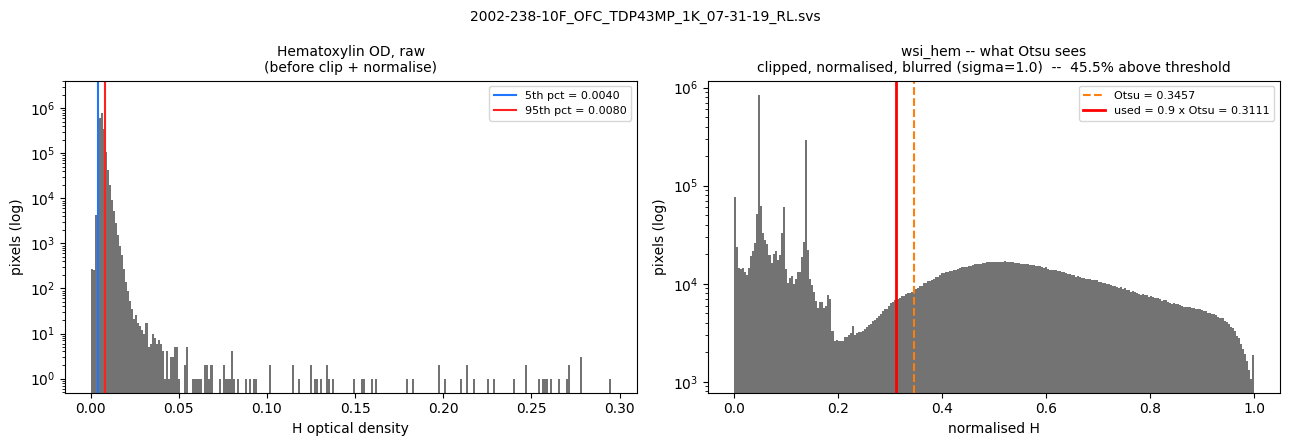

{'lo': 0.004022921901196241,
 'hi': 0.008047382347285748,
 'otsu': 0.34570229053497314,
 'threshold': 0.3111320436000824,
 'pct_above': 45.512174717208396}

In [11]:
histogram_threshold(curr_WSI_path)

### [3] Updated Tissue Extraction 081026

In [36]:
def valley_threshold(gray_inv, bins=None, smooth_div=100, peak_prom=0.05, valley_prom=0.005):
    """Threshold at the first valley to the right of the background (leftmost) peak.

    Background is blank glass, so it is always the leftmost mode of `1 - gray`.
    Anchoring there makes the threshold independent of what the tissue mode looks
    like, unlike Otsu, which is driven by the whole histogram.

    bins        : histogram bins, default Rice rule 2 * N**(1/3)
    smooth_div  : histogram smoothed with sigma = bins / smooth_div (~1% of the range),
                  which suppresses the RGB->gray quantization comb
    peak_prom   : min peak prominence as a fraction of the tallest bin
    valley_prom : min valley prominence, same units

    Returns (threshold, bg_peak, centers, hist). `threshold` is None if no valley exists.
    """
    if bins is None:
        bins = int(np.ceil(2 * gray_inv.size ** (1 / 3)))

    hist, edges = np.histogram(gray_inv, bins=bins, range=(gray_inv.min(), gray_inv.max()))
    hist = gaussian_filter1d(hist.astype(float), bins / smooth_div)
    centers = 0.5 * (edges[:-1] + edges[1:])

    peaks,   _ = find_peaks( hist, prominence=peak_prom * hist.max())
    valleys, _ = find_peaks(-hist, prominence=valley_prom * hist.max())

    i_bg = peaks[0] if len(peaks) else int(np.argmax(hist))
    right = valleys[valleys > i_bg]
    thresh = centers[right[0]] if len(right) else None

    return thresh, centers[i_bg], centers, hist


In [39]:
def get_tissue_mask_updated(WSI_file_name, tb, debug_path=None):
    """Tissue mask from RGB grayscale, thresholded at the background/tissue valley.

    If `debug_path` is given, a per-stage debug figure is written to
    `debug_path/<WSI_file_name with .svs replaced by _debug.png>`.
    """

    # --- (1) RGB --> inverted grayscale ---
    # Tissue is DARKER than the slide background, so invert: high = tissue.
    GRAY_SIGMA = 1.0  # blurring amount
    gray_inv = 1.0 - rgb2gray(tb.img.astype(np.float32) / 255.0).astype(np.float32)
    wsi_gray = gaussian(gray_inv, sigma=GRAY_SIGMA)  # blur to stabilize thresholding

    # --- (2) Threshold at the valley right of the background peak ---
    thresh, bg_peak, hist_x, hist_y = valley_threshold(wsi_gray)
    if thresh is None:
        raise ValueError('no background/tissue valley found in the histogram')

    # --- (3) Initial mask + smoothing (closing → opening) ---
    tissue_mask_bool = (wsi_gray > thresh).astype(np.uint8)
    tissue_mask = sana.image.frame_like(tb, tissue_mask_bool)
    tissue_mask.to_short()
    tissue_mask.apply_morphology_filter(sana.filter.MorphologyFilter('closing', 'ellipse', 2))
    tissue_mask.apply_morphology_filter(sana.filter.MorphologyFilter('opening', 'ellipse', 15))
    mask_smooth = (tissue_mask.img.squeeze() > 0) # Back to np nadaary

    # --- (4) Connected-component gating with border logic (Remove tissue touching the WSI edge) ---
    mask = mask_smooth.astype(np.uint8)
    Hh, Ww = mask.shape
    labels = measure.label(mask, connectivity=2)

    if labels.max() == 0: # No tissue found, return empty mask
        kept = np.zeros_like(mask, dtype=np.uint8)
    else: # Tissue found, perform connected-component analysis and border gating
        # ====== Only the components that are touching the border and less than 5% of the WSI is dropped ======
        # Get the properties of the labeled regions
        props = measure.regionprops(labels)

        def touches_border(p): # Check if a region touches the border of the image
            minr, minc, maxr, maxc = p.bbox  # maxr/maxc exclusive
            return (minr == 0) or (minc == 0) or (maxr == Hh) or (maxc == Ww)

        # Prepare arrays for areas, labels, and border-touching flags
        areas = np.array([p.area for p in props])
        lbls  = np.array([p.label for p in props])
        touch = np.array([touches_border(p) for p in props])

        # Get big border-touching blobs 
        area_thresh = 0.05 * Hh * Ww  # keep big border-touching blobs
        big_border_labels = set(lbls[(touch) & (areas >= area_thresh)])
        largest_label = lbls[np.argmax(areas)]
        keep_labels = set(lbls[~touch]) | {largest_label} | big_border_labels

        # Kept tissue mask component Mask
        kept = np.isin(labels, list(keep_labels)).astype(np.uint8)

    # --- (5) Fill small internal holes only ---
    SMALL_HOLE_FRAC = 0.001  # 0.1% of tissue area
    kept_bool = kept.astype(bool)
    tissue_area_px = int(kept_bool.sum())
    min_hole_area_px = max(1, int(round(SMALL_HOLE_FRAC * tissue_area_px)))
    kept_filled = remove_small_holes(kept_bool, area_threshold=min_hole_area_px, connectivity=2)

    # --- (6) Finalize (SANA frame) ---
    kept = kept_filled.astype(np.uint8)
    tissue_mask = sana.image.frame_like(tb, kept)
    tissue_mask.to_short()

    # --- (7) Per-stage debug figure ---
    if debug_path is not None:
        os.makedirs(debug_path, exist_ok=True)

        TISSUE_C, BG_C, HOLE_C = 'red', '#1f77ff', '#00e5ff'

        def _panel(ax, base, title, overlays=(), contours=(), cmap=None, vmin=None, vmax=None):
            """Show `base` with (bool mask, color, alpha, label) overlays and
            (bool mask, color, linewidth, label) contour outlines.

            Overlays are resampled with the image when the panel is smaller than the
            mask, so features only a few pixels across get washed out.  Contours are
            stroked in figure space and stay crisp at any dpi -- use them to mark
            small features such as the filled holes.
            """
            ax.imshow(base, cmap=cmap, vmin=vmin, vmax=vmax)
            handles = []
            for m, color, alpha, label in overlays:
                m = np.asarray(m, dtype=bool)
                ax.imshow(np.ma.masked_where(~m, m), cmap=ListedColormap([color]), alpha=alpha)
                if label:
                    handles.append(Patch(facecolor=color, alpha=alpha, label=label))
            for m, color, lw, label in contours:
                m = np.asarray(m, dtype=bool)
                if m.any():
                    ax.contour(m.astype(float), levels=[0.5], colors=[color], linewidths=lw)
                if label:
                    handles.append(Line2D([], [], color=color, lw=max(lw, 1.2), label=label))
            if handles:
                ax.legend(handles=handles, loc='lower left', fontsize=7, framealpha=0.8)
            ax.set_title(title, fontsize=9)
            ax.axis('off')

        # Only the holes that step (5) actually filled in
        holes_filled = kept_filled & ~kept_bool
        final_bool = tissue_mask.img.squeeze() > 0
        pct = lambda m: 100 * np.asarray(m, dtype=bool).mean()

        # Display-only contrast stretch: a few near-black specks otherwise set the
        # white point far above the tissue mode and panel (1) renders nearly black.
        gray_vmax = float(np.percentile(wsi_gray, 99.5))

        fig, axes = plt.subplots(2, 4, figsize=(24, 12))

        _panel(axes[0, 0], tb.img, 'Thumbnail')
        _panel(axes[0, 1], wsi_gray,
               f'(1) Inverted grayscale (1 - gray), sigma={GRAY_SIGMA}\n'
               f'displayed over [0, {gray_vmax:.3f}] (99.5th pct)',
               cmap='gray', vmin=0.0, vmax=gray_vmax)

        ax = axes[0, 2]
        ax.plot(hist_x, hist_y, color='0.35', lw=1)
        ax.axvline(bg_peak, color=BG_C, lw=1.5, label=f'background peak = {bg_peak:.4f}')
        ax.axvline(thresh, color=TISSUE_C, lw=2, label=f'valley threshold = {thresh:.4f}')
        ax.set_yscale('log')
        ax.set_xlabel('1 - gray')
        ax.set_ylabel('pixels (log)')
        ax.legend(fontsize=7)
        ax.set_title(f'(2) Smoothed histogram  ({len(hist_x)} bins)', fontsize=9)

        _panel(axes[0, 3], tb.img,
               f'(3) Mask right after thresholding  —  {pct(tissue_mask_bool):.1f}%',
               overlays=[(tissue_mask_bool, TISSUE_C, 0.4, None)])
        _panel(axes[1, 0], tb.img,
               f'(4) After smoothing: closing(2) → opening(15)  —  {pct(mask_smooth):.1f}%',
               overlays=[(mask_smooth, TISSUE_C, 0.4, None)])
        _panel(axes[1, 1], tb.img,
               f'(5) After connected-component / border gating  —  {pct(kept_bool):.1f}%',
               overlays=[(kept_bool, TISSUE_C, 0.4, None)])
        _panel(axes[1, 2], tb.img,
               f'(6) Small internal holes filled (≤{min_hole_area_px} px)',
               overlays=[(kept_bool, TISSUE_C, 0.4, 'mask before fill'),
                         (holes_filled, HOLE_C, 1.0, None)],
               contours=[(holes_filled, HOLE_C, 1.0,
                          f'filled holes ({int(holes_filled.sum())} px, {pct(holes_filled):.2f}%)')])
        _panel(axes[1, 3], tb.img,
               f'(7) Final tissue mask  —  {pct(final_bool):.1f}%',
               overlays=[(final_bool, TISSUE_C, 0.4, None)])

        fig.suptitle(WSI_file_name, fontsize=12)
        fig.tight_layout()

        out_name = os.path.splitext(os.path.basename(WSI_file_name))[0] + '_debug.png'
        out_path = os.path.join(debug_path, out_name)
        fig.savefig(out_path, dpi=150)
        plt.close(fig)
        print(f'debug figure saved to: {out_path}')

    return tissue_mask

In [40]:
tissue_mask = get_tissue_mask_updated(WSI_file_name, tb, debug_path = '/Users/hyroh/UPenn PhD/Published_Code/NEUSEG/debug/tissue_extraction_debug')
tissue_bodies, tissue_holes = tissue_mask.to_polygons()

debug figure saved to: /Users/hyroh/UPenn PhD/Published_Code/NEUSEG/debug/tissue_extraction_debug/2002-238-10F_OFC_TDP43MP_1K_07-31-19_RL_debug.png


# Batch Debug Figures

Run `get_tissue_mask` over every `.svs` in a cohort and write one debug figure per slide,
mirroring the source directory structure under `tissue_extraction_debug/`:

```
/Volumes/Extreme SSD/bvFTD_Eval_cohort/FTLD-TAU/<slide>.svs
    -> debug/tissue_extraction_debug/bvFTD_Eval_cohort/FTLD-TAU/<slide>.png
```

Slides whose `.png` already exists are skipped, so the cell can be re-run to resume.

In [7]:
cohort_dir = "/Volumes/Extreme SSD/bvFTD_Eval_cohort"
debug_root = "/Volumes/Extreme SSD/bvFTD_Eval_cohort/debug/tissue_extraction_debug"
os.makedirs(debug_root, exist_ok=True)

# Output mirrors the cohort layout: <debug_root>/<cohort>/<subdir>/<slide>.png
cohort_out = os.path.join(debug_root, os.path.basename(cohort_dir.rstrip('/')))

svs_paths = sorted(glob.glob(os.path.join(cohort_dir, '**', '*.svs'), recursive=True))
print(f"{len(svs_paths)} slides under {cohort_dir}")

batch_logger = sana.logging.Logger('quiet', os.path.join(tempfile.gettempdir(), 'tissue_extraction_batch.pkl'))
failures, n_done, n_skipped = [], 0, 0

for i, svs_path in enumerate(svs_paths, 1):
    rel_dir = os.path.dirname(os.path.relpath(svs_path, cohort_dir))  # e.g. 'FTLD-TAU'
    file_name = os.path.basename(svs_path)
    out_dir = os.path.join(cohort_out, rel_dir)
    out_png = os.path.join(out_dir, os.path.splitext(file_name)[0] + '.png')

    # Already rendered -> skip, so an interrupted run can just be re-run
    if os.path.exists(out_png):
        n_skipped += 1
        continue

    print(f"[{i}/{len(svs_paths)}] {os.path.join(rel_dir, file_name)}")
    try:
        slide_loader = sana.slide.Loader(batch_logger, svs_path)
        slide_tb = slide_loader.load_thumbnail()
        get_tissue_mask(file_name, slide_tb, debug_path=out_dir)
        n_done += 1
        
        # Memory saving
        slide_loader.close()
        del slide_tb
    except Exception as e:
        print(f"    FAILED  {type(e).__name__}: {e}")
        failures.append((svs_path, f"{type(e).__name__}: {e}"))

print(f"\ndone: {n_done} rendered, {n_skipped} already present, {len(failures)} failed")
for path, err in failures:
    print(f"  {path}  ->  {err}")

529 slides under /Volumes/Extreme SSD/bvFTD_Eval_cohort
[519/529] FTLD-TDP/2020-044-30F_N_aCING_TDP43_6K_01-24-23_ML.svs
debug figure saved to: /Volumes/Extreme SSD/bvFTD_Eval_cohort/debug/tissue_extraction_debug/bvFTD_Eval_cohort/FTLD-TDP/2020-044-30F_N_aCING_TDP43_6K_01-24-23_ML.png
[520/529] FTLD-TDP/2020-044-55F_R_OFC_TDP43_6K_01-24-23_ML.svs
debug figure saved to: /Volumes/Extreme SSD/bvFTD_Eval_cohort/debug/tissue_extraction_debug/bvFTD_Eval_cohort/FTLD-TDP/2020-044-55F_R_OFC_TDP43_6K_01-24-23_ML.png
[521/529] FTLD-TDP/2020-044-58F_R_aCING_TDP43_6K_01-24-23_ML.svs
debug figure saved to: /Volumes/Extreme SSD/bvFTD_Eval_cohort/debug/tissue_extraction_debug/bvFTD_Eval_cohort/FTLD-TDP/2020-044-58F_R_aCING_TDP43_6K_01-24-23_ML.png
[522/529] FTLD-TDP/2020-212-04F_L_MFC_TDP43_6K_06-07-22_EX.svs
debug figure saved to: /Volumes/Extreme SSD/bvFTD_Eval_cohort/debug/tissue_extraction_debug/bvFTD_Eval_cohort/FTLD-TDP/2020-212-04F_L_MFC_TDP43_6K_06-07-22_EX.png
[523/529] FTLD-TDP/2020-212-05F_

# Batch Debug Figures — Updated Pipeline

Same batch as above, but running `get_tissue_mask_updated` (grayscale + valley threshold)
and writing to `tissue_extraction_debug_new/` so the two can be compared side by side:

```
/Volumes/Extreme SSD/bvFTD_Eval_cohort/FTLD-TAU/<slide>.svs
    -> .../debug/tissue_extraction_debug_new/bvFTD_Eval_cohort/FTLD-TAU/<slide>_debug.png
```

Slides whose `_debug.png` already exists are skipped, so the cell can be re-run to resume.
Slides where no background/tissue valley is found raise and land in `failures`.

In [ ]:
cohort_dir = "/Volumes/Extreme SSD/bvFTD_Eval_cohort"
debug_root = "/Volumes/Extreme SSD/bvFTD_Eval_cohort/debug/tissue_extraction_debug_new"
os.makedirs(debug_root, exist_ok=True)

# Output mirrors the cohort layout: <debug_root>/<cohort>/<subdir>/<slide>_debug.png
cohort_out = os.path.join(debug_root, os.path.basename(cohort_dir.rstrip('/')))

svs_paths = sorted(glob.glob(os.path.join(cohort_dir, '**', '*.svs'), recursive=True))
print(f"{len(svs_paths)} slides under {cohort_dir}")

batch_logger = sana.logging.Logger('quiet', os.path.join(tempfile.gettempdir(), 'tissue_extraction_batch_new.pkl'))
failures, n_done, n_skipped = [], 0, 0

for i, svs_path in enumerate(svs_paths, 1):
    rel_dir = os.path.dirname(os.path.relpath(svs_path, cohort_dir))  # e.g. 'FTLD-TAU'
    file_name = os.path.basename(svs_path)
    out_dir = os.path.join(cohort_out, rel_dir)
    # get_tissue_mask_updated writes '<slide>_debug.png', so match that here
    out_png = os.path.join(out_dir, os.path.splitext(file_name)[0] + '_debug.png')

    # Already rendered -> skip, so an interrupted run can just be re-run
    if os.path.exists(out_png):
        n_skipped += 1
        continue

    print(f"[{i}/{len(svs_paths)}] {os.path.join(rel_dir, file_name)}")
    slide_loader = None
    try:
        slide_loader = sana.slide.Loader(batch_logger, svs_path)
        slide_tb = slide_loader.load_thumbnail()
        get_tissue_mask_updated(file_name, slide_tb, debug_path=out_dir)
        n_done += 1
    except Exception as e:
        print(f"    FAILED  {type(e).__name__}: {e}")
        failures.append((svs_path, f"{type(e).__name__}: {e}"))
    finally:
        # Memory saving -- must run on the failure path too
        if slide_loader is not None:
            slide_loader.close()

print(f"\ndone: {n_done} rendered, {n_skipped} already present, {len(failures)} failed")
for path, err in failures:
    print(f"  {path}  ->  {err}")

# Batch Comparison — Old vs New Final Mask

One figure per slide: thumbnail, final mask from `get_tissue_mask` (hematoxylin + Otsu),
final mask from `get_tissue_mask_updated` (grayscale + valley threshold). The IoU between
the two masks goes in the figure title and is collected in `comparison`, so sorting that
list points straight at the slides where the two pipelines disagree.

In [ ]:
def save_mask_comparison(file_name, tb, out_path):
    """Thumbnail | final mask from get_tissue_mask | final mask from get_tissue_mask_updated."""
    old = get_tissue_mask(file_name, tb).img.squeeze() > 0          # hematoxylin + Otsu
    new = get_tissue_mask_updated(file_name, tb).img.squeeze() > 0  # grayscale + valley
    iou = (old & new).sum() / max((old | new).sum(), 1)

    fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharex=True, sharey=True)
    axes[0].imshow(tb.img)
    axes[0].set_title('Thumbnail', fontsize=10)
    for ax, m, name in [(axes[1], old, 'get_tissue_mask  (hematoxylin + Otsu)'),
                        (axes[2], new, 'get_tissue_mask_updated  (grayscale + valley)')]:
        ax.imshow(tb.img)
        ax.imshow(np.ma.masked_where(~m, m), cmap=ListedColormap(['red']), alpha=0.4)
        ax.set_title(f'{name}  —  {100 * m.mean():.1f}%', fontsize=10)
    for ax in axes:
        ax.axis('off')

    fig.suptitle(f'{file_name}     IoU = {iou:.4f}', fontsize=11)
    fig.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return iou


cohort_dir = "/Volumes/Extreme SSD/bvFTD_Eval_cohort"
debug_root = "/Volumes/Extreme SSD/bvFTD_Eval_cohort/debug/tissue_extraction_debug_new_comparison"
os.makedirs(debug_root, exist_ok=True)

# Output mirrors the cohort layout: <debug_root>/<cohort>/<subdir>/<slide>_comparison.png
cohort_out = os.path.join(debug_root, os.path.basename(cohort_dir.rstrip('/')))

svs_paths = sorted(glob.glob(os.path.join(cohort_dir, '**', '*.svs'), recursive=True))
print(f"{len(svs_paths)} slides under {cohort_dir}")

batch_logger = sana.logging.Logger('quiet', os.path.join(tempfile.gettempdir(), 'tissue_extraction_batch_cmp.pkl'))
failures, comparison, n_done, n_skipped = [], [], 0, 0

for i, svs_path in enumerate(svs_paths, 1):
    rel_dir = os.path.dirname(os.path.relpath(svs_path, cohort_dir))  # e.g. 'FTLD-TAU'
    file_name = os.path.basename(svs_path)
    out_dir = os.path.join(cohort_out, rel_dir)
    out_png = os.path.join(out_dir, os.path.splitext(file_name)[0] + '_comparison.png')

    # Already rendered -> skip, so an interrupted run can just be re-run
    if os.path.exists(out_png):
        n_skipped += 1
        continue

    print(f"[{i}/{len(svs_paths)}] {os.path.join(rel_dir, file_name)}")
    slide_loader = None
    try:
        slide_loader = sana.slide.Loader(batch_logger, svs_path)
        slide_tb = slide_loader.load_thumbnail()
        iou = save_mask_comparison(file_name, slide_tb, out_png)
        comparison.append((iou, os.path.join(rel_dir, file_name)))
        print(f"    IoU = {iou:.4f}  ->  {out_png}")
        n_done += 1
    except Exception as e:
        print(f"    FAILED  {type(e).__name__}: {e}")
        failures.append((svs_path, f"{type(e).__name__}: {e}"))
    finally:
        # Memory saving -- must run on the failure path too
        if slide_loader is not None:
            slide_loader.close()

print(f"\ndone: {n_done} rendered, {n_skipped} already present, {len(failures)} failed")
for path, err in failures:
    print(f"  {path}  ->  {err}")

# Lowest IoU first -- these are the slides where the two pipelines disagree most
if comparison:
    print('\nmost divergent slides:')
    for iou, name in sorted(comparison)[:20]:
        print(f"  {iou:.4f}  {name}")